# 📊 News Fetcher — Live Analysis Dashboard

**Date:** 2026-07-20  
**Database:** `news.db` (populated by `fetch_news.py` polling every 60s)  
**Sources:** NPR (text.npr.org) · BBC (RSS) · CNN (lite.cnn.com)

This notebook connects to the live SQLite database, fetches fresh headlines on demand, and runs analysis — including article body content extraction.

---

### 🗄️ Schema

```
articles (
    id            INTEGER PRIMARY KEY,
    source        TEXT,              -- 'npr', 'bbc', or 'cnn'
    title         TEXT,              -- headline text (updated each time we re-see the URL)
    url           TEXT UNIQUE,       -- article link (dedup key)
    first_seen_at TEXT,              -- when we FIRST captured this headline (never changes)
    last_seen_at  TEXT,              -- most recent time we saw this headline (updated each poll)
    published_at  TEXT,              -- original publication date from publisher (if available)
    snippet       TEXT,              -- short description (BBC RSS only)
    content       TEXT,              -- full article body text (fetched ONCE)
    has_body      INTEGER DEFAULT 0  -- 0 = body not fetched yet, 1 = body fetched
)
```

**Key design decisions:**
- `first_seen_at` / `last_seen_at` — we separate "when did we first discover this article" from "when did we last confirm it's still on the front page." The poller updates `last_seen_at` (and title) every cycle but never touches `first_seen_at`.
- `has_body` — a boolean flag. Headlines are fetched every cycle (fast, ~2s). Body text is only fetched once (slow, ~8s per article), and only when `has_body = 0`. This keeps the poller fast while still capturing full content eventually.

---

### 🔑 How Does Deduplication Work?

**`url TEXT UNIQUE`** at the schema level. The application uses `INSERT` for new URLs, and `UPDATE last_seen_at, title` for existing ones — so headlines stay current while avoiding duplicates.

---

### 🗂️ What are `news.db-shm` and `news.db-wal`?

You may see these two extra files appear next to `news.db`. They are **normal** — created by SQLite when WAL mode is active:

| File | Purpose |
|---|---|
| `news.db-wal` | **Write-Ahead Log** — new data is written here first before being periodically merged (checkpointed) into the main `.db` file. Allows concurrent reads while writes are happening. |
| `news.db-shm` | **Shared Memory** — a small index used by all connections to coordinate access to the WAL file. Never delete this while a connection is open. |

When the database connection closes cleanly (Cell 8), SQLite automatically merges the WAL back into `news.db` and the `-wal`/`-shm` files may shrink or disappear. **Never delete them while `fetch_news.py` is running** — they contain uncommitted data.

---
## 🔌 Cell 1: Connect to the Database

Opens `news.db` using Python's built-in `sqlite3` module with `row_factory` set to `sqlite3.Row` so columns can be accessed by name (like `row['source']`). Prints a quick health summary:

- **Total article count** across all sources
- **Source breakdown** — how many articles from NPR, BBC, CNN
- **Time range** — earliest and latest fetch timestamps

This cell must be run first before any other cell; it opens the shared database connection used by the rest of the notebook.

In [3]:
# Cell 1: Imports & DB Connection
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timezone, timedelta
from pathlib import Path
from collections import Counter
import re

DB_PATH = Path("news.db")

conn = sqlite3.connect(str(DB_PATH))
conn.row_factory = sqlite3.Row

print("✓ Connected to", DB_PATH.resolve())
total = conn.execute("SELECT COUNT(*) FROM articles").fetchone()[0]
with_body = conn.execute("SELECT COUNT(*) FROM articles WHERE has_body = 1").fetchone()[0]
print(f"  Total articles: {total:,}  ({with_body} with body text)")

# Show source breakdown
by_source = conn.execute(
    "SELECT source, COUNT(*) as cnt FROM articles GROUP BY source ORDER BY cnt DESC"
).fetchall()
print("\n  Source breakdown:")
for row in by_source:
    body_col = conn.execute(
        "SELECT COUNT(*) FROM articles WHERE source = ? AND has_body = 1", (row['source'],)
    ).fetchone()[0]
    print(f"    {row['source'].upper():6s}: {row['cnt']:>6,}  ({body_col} with body)")

# Show time range
time_range = conn.execute(
    "SELECT MIN(first_seen_at) as earliest, MAX(last_seen_at) as latest FROM articles"
).fetchone()
if time_range['earliest']:
    print(f"\n  First article seen: {time_range['earliest'][:19]}")
    print(f"  Last update:        {time_range['latest'][:19]}")

✓ Connected to D:\Deepin\Programming\20260719 OpenGovernment\news_fetcher\news.db
  Total articles: 151  (0 with body text)

  Source breakdown:
    CNN   :    101  (0 with body)
    BBC   :     30  (0 with body)
    NPR   :     20  (0 with body)

  First article seen: 2026-07-19T17:44:10
  Last update:        2026-07-19T17:45:37


---
## 🚀 Cell 2: Fetch Fresh Headlines + Article Body Text

Triggers a live poll to fetch the latest headlines from all three sources. Runs in **two phases** to prevent hanging:

**Phase 1 — Headlines (fast, ~2 seconds):** Fetches the main page / RSS feed for each source in parallel using `ThreadPoolExecutor`. New articles are inserted into `news.db` with `INSERT OR IGNORE` (duplicate URLs are silently skipped).

**Phase 2 — Body Text (optional, time-guarded):** For the top `BODY_COUNT` (default 3) articles per source that don't already have body text, it fetches the full article page with a short **8-second timeout per article** to prevent hanging. Body text is stored in the `content` column.

> **Why two phases?** Earlier versions fetched body text inside the headline thread, which could stall for up to 100 seconds if BBC or CNN pages were slow. Separating the phases means headlines are always saved immediately, and body enrichment best-effort. If Phase 2 takes too long, you can interrupt it without losing headlines.

In [4]:
# Cell 2: Fetch Fresh Headlines (fast) + Article Body Text (once, when has_body = 0)
#
# Strategy:
#   Headlines → fetched every time. new URLs get first_seen_at = now.
#   Existing URLs → last_seen_at & title UPDATED.
#   Body text → only for articles where has_body = 0 (once per article).

import requests
from bs4 import BeautifulSoup
import xml.etree.ElementTree as ET
from concurrent.futures import ThreadPoolExecutor, as_completed
import time

HEADERS = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/120.0.0.0 Safari/537.36"}
TIMEOUT = 20
BODY_TIMEOUT = 8
BODY_COUNT = 3

def ext_npr_body(url):
    try:
        r = requests.get(url, headers=HEADERS, timeout=BODY_TIMEOUT)
        a = BeautifulSoup(r.text, "html.parser").find("article")
        return "\n\n".join(p.get_text(" ", strip=True) for p in a.find_all("p") if len(p.get_text(strip=True)) > 40) if a else ""
    except: return ""

def ext_bbc_body(url):
    try:
        r = requests.get(url, headers=HEADERS, timeout=BODY_TIMEOUT)
        s = BeautifulSoup(r.text, "html.parser")
        parts = [b.get_text(" ", strip=True) for b in s.select("[data-component='text-block']") if len(b.get_text(strip=True)) > 40]
        if not parts:
            a = s.find("article")
            if a: parts = [p.get_text(" ", strip=True) for p in a.find_all("p") if len(p.get_text(strip=True)) > 40]
        return "\n\n".join(parts[:20])
    except: return ""

def ext_cnn_body(url):
    try:
        r = requests.get(url, headers=HEADERS, timeout=BODY_TIMEOUT)
        skip = ("source:", "updated:", "by ")
        parts = [p.get_text(" ",strip=True) for p in BeautifulSoup(r.text,"html.parser").find_all("p")
                 if len(p.get_text(strip=True)) > 40 and not p.get_text(strip=True).lower().startswith(skip)]
        return "\n\n".join(parts)
    except: return ""

_ext = {"npr": ext_npr_body, "bbc": ext_bbc_body, "cnn": ext_cnn_body}

def fetch_npr():
    r = requests.get("https://text.npr.org", headers=HEADERS, timeout=TIMEOUT)
    s = BeautifulSoup(r.text, "html.parser")
    return [{"source":"npr","title":l.get_text(strip=True),"url":"https://text.npr.org"+l.get("href"),
             "published_at":"","snippet":"","content":""}
            for l in s.find_all("a") if l.get("href","").startswith("/") and 15 < len(l.get_text(strip=True)) < 300]

def fetch_bbc():
    r = requests.get("https://feeds.bbci.co.uk/news/rss.xml", headers=HEADERS, timeout=TIMEOUT)
    root = ET.fromstring(r.content)
    arts = []
    for item in root.findall(".//item"):
        t = item.find("title"); u = item.find("link"); p = item.find("pubDate"); d = item.find("description")
        title = t.text.strip() if t is not None and t.text else ""
        url = u.text.strip() if u is not None and u.text else ""
        pub = p.text.strip() if p is not None and p.text else ""
        desc = d.text.strip()[:200] if d is not None and d.text else ""
        if title and url: arts.append({"source":"bbc","title":title,"url":url,"published_at":pub,"snippet":desc,"content":""})
    return arts

def fetch_cnn():
    r = requests.get("https://lite.cnn.com", headers=HEADERS, timeout=TIMEOUT)
    s = BeautifulSoup(r.text, "html.parser")
    return [{"source":"cnn","title":l.get_text(strip=True),"url":"https://lite.cnn.com"+l.get("href"),
             "published_at":"","snippet":"","content":""}
            for l in s.find_all("a") if l.get("href","").startswith("/") and 15 < len(l.get_text(strip=True)) < 300]

# ====================================================================
# Phase 1: Save headlines (fast)
# ====================================================================
now = datetime.now(timezone.utc).isoformat()
fetchers = {"npr": fetch_npr, "bbc": fetch_bbc, "cnn": fetch_cnn}
new_counts = {}

print("🚀 Phase 1: Fetching headlines …\n")
with ThreadPoolExecutor(max_workers=3) as pool:
    futures = {pool.submit(fn): name for name, fn in fetchers.items()}
    for f in as_completed(futures):
        name = futures[f]; articles = f.result()
        inserted = 0; updated = 0
        for a in articles:
            cur = conn.execute(
                "INSERT OR IGNORE INTO articles (source,title,url,first_seen_at,last_seen_at,published_at,snippet,content,has_body) "
                "VALUES (?,?,?,?,?,?,?,?,0)",
                (a["source"],a["title"],a["url"],now,now,a.get("published_at"),a.get("snippet",""),a.get("content","")))
            if cur.rowcount > 0:
                inserted += 1
            else:
                conn.execute("UPDATE articles SET last_seen_at=?, title=? WHERE url=?",
                             (now, a["title"], a["url"]))
                updated += 1
        conn.commit()
        new_counts[name] = inserted
        print(f"  ✅ {name.upper():6s} → {len(articles):3d} headlines, {inserted:3d} new, {updated:3d} updated")

# ====================================================================
# Phase 2: Enrich body text — only for articles where has_body = 0
# ====================================================================
print(f"\n📖 Phase 2: Body text for up to {BODY_COUNT} articles per source (has_body=0 only)…\n")
body_updated = 0
for source in ["npr","bbc","cnn"]:
    rows = conn.execute(
        "SELECT id, url FROM articles WHERE source=? AND has_body=0 ORDER BY first_seen_at DESC LIMIT ?",
        (source, BODY_COUNT)).fetchall()
    for r in rows:
        body = _ext[source](r["url"])
        if len(body) > 100:
            conn.execute("UPDATE articles SET content=?, has_body=1 WHERE id=?", (body, r["id"]))
            body_updated += 1
        time.sleep(0.2)
conn.commit()
print(f"  📝 Body text updated for {body_updated} article(s)")

total_all = conn.execute("SELECT COUNT(*) FROM articles").fetchone()[0]
with_body = conn.execute("SELECT COUNT(*) FROM articles WHERE has_body=1").fetchone()[0]
print(f"\n📊 DB: {total_all:,} total | {with_body} with body text | {sum(new_counts.values())} new")

🚀 Phase 1: Fetching headlines …

  ✅ BBC    →  31 headlines,   0 new,  31 updated
  ✅ CNN    → 100 headlines,   0 new, 100 updated
  ✅ NPR    →  20 headlines,   0 new,  20 updated

📖 Phase 2: Body text for up to 3 articles per source (has_body=0 only)…

  📝 Body text updated for 9 article(s)

📊 DB: 151 total | 9 with body text | 0 new


---
## 📰 Cell 3: Latest 30 Headlines

Reads the 30 most recently fetched articles (across all sources) from the database and displays them as a pandas DataFrame. Each row shows:

- **source** — npr, bbc, or cnn  
- **title** — the full headline text (truncated to 100 chars for display)  
- **url** — the direct link to the article page  
- **fetched_at** — UTC timestamp of when we captured it

Useful for a quick scan of what the poller is seeing right now.

In [ ]:
# Cell 3: Latest 30 Headlines — All Sources
df_recent = pd.read_sql_query(
    "SELECT source, title, url, first_seen_at, has_body FROM articles ORDER BY first_seen_at DESC LIMIT 30",
    conn
)
df_recent["first_seen_at"] = pd.to_datetime(df_recent["first_seen_at"])
df_recent.index = range(1, len(df_recent) + 1)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 200)
print(df_recent.to_string())

   source                                                                                                                          title                                                                                                         url                    first_seen_at  has_body
1     cnn                                                                                                  Go to the full CNN experience                                                                                        https://www.cnn.com/ 2026-07-19 17:44:10.785473+00:00         0
2     cnn                                                                         Two more of Brad Pitt’s kids want to ditch his surname                        https://lite.cnn.com/2026/07/16/entertainment/brad-pitt-kids-ditch-surname-scli-intl 2026-07-19 17:44:10.785473+00:00         0
3     cnn                                                      Gas is nearly $4 again and diesel just topped $5. It’s not what you think

: 

---
## 📖 Cell 3b: View Full Article Body Text

Displays the **complete article body** for the most recent article in the database that has content stored. The text is word-wrapped at 100 characters for readability and separated into paragraphs.

- Shows source, title, URL, and fetch timestamp as a header
- Prints the full `content` field split by paragraph breaks
- If no articles have body text yet, it prompts you to run Cell 2 first

Running Cell 2 will populate up to 3 articles per source with full body text.

In [ ]:
# Cell 3b: Display Full Article Content for the Most Recent Article with Body Text
import textwrap

row = conn.execute(
    "SELECT source, title, url, content, first_seen_at FROM articles "
    "WHERE has_body = 1 ORDER BY first_seen_at DESC LIMIT 1"
).fetchone()

if row:
    print(f"📰 Source:  {row['source'].upper()}")
    print(f"📌 Title:   {row['title']}")
    print(f"🔗 URL:     {row['url']}")
    print(f"🕐 First seen: {row['first_seen_at'][:19]}")
    print("─" * 78)
    body = row["content"]
    for line in body.split("\n\n"):
        wrapped = textwrap.fill(line, width=100)
        print(wrapped)
        print()
else:
    print("⚠️ No articles with body text yet. Run Cell 2 first to fetch content.")

📰 Source:  BBC
📌 Title:   Record numbers of honours for working class heroes
🔗 URL:     https://www.bbc.co.uk/news/articles/cpd3dd3vv65o?at_medium=RSS&at_campaign=rss
🕐 Fetched: 2026-07-19T17:00:13
──────────────────────────────────────────────────────────────────────────────
Clive Lawrence has been part of a drive to widen access to the honours system

"I always had the perception that you only got an honour if you were rich or famous," says Clive
Lawrence.

His start in life had been free school meals and growing up on a council estate in Derbyshire, but
the former head teacher has been made an Officer of the British Empire (OBE).

He's part of a quiet revolution in the honours system, which has deliberately sought to make the
awards less socially exclusive and to have a fairer spread of winners around the country.

That change followed an analysis by the BBC last year of the New Year Honours in 2025 which showed
that among higher winners - such as Commanders of the British Empire (C

---
## 📋 Cell 4: Top 20 Headlines — By Source

Queries the database separately for each source (NPR, BBC, CNN) and prints the most recent 20 headlines from each. This is useful for:

- **Comparing coverage** — see what stories each outlet is prioritizing
- **Spotting exclusives** — stories that only one source is covering
- **Identifying duplicates** — the same story reported across multiple outlets

Output is three separate sections, one per source, each sorted by `fetched_at` descending.

In [ ]:
# Cell 4: Top 20 Headlines by Source
for src in ["npr", "bbc", "cnn"]:
    df_src = pd.read_sql_query(
        "SELECT title, url, first_seen_at, has_body FROM articles WHERE source = ? ORDER BY first_seen_at DESC LIMIT 20",
        conn, params=(src,)
    )
    df_src.index = range(1, len(df_src) + 1)
    body_counts = f"({sum(df_src['has_body'])} with body)"
    print(f"\n{'=' * 80}")
    print(f"  📰 {src.upper()} — Latest 20 Headlines  {body_counts}")
    print(f"{'=' * 80}")
    print(df_src[["title", "has_body"]].to_string())


  📰 NPR — Latest 20 Headlines
                                                                                             title
1                   Violence repeatedly erupts in dementia care despite warnings, inspections show
2                                   U.S. launches new airstrikes to 'punish' Iran for troop deaths
3               Andrew and Tristan Tate arrested in Florida on charges of rape and sex trafficking
4           Argentina, Spain and their stars Lionel Messi and Lamine Yamal meet in World Cup final
5                                              Who is Andy Burnham, the U.K.'s new prime minister?
6                         Hunter Biden says being 'stripped naked in the public square' was a gift
7                      Air quality improving in Northeast, while wildfire smoke hangs over Midwest
8                  MLS works to bring in a new generation of fans as the World Cup comes to an end
9                                          5 clever design tricks to make a sm

---
## 📈 Cell 5: Hourly Article Count Trend

Aggregates article counts by hour (truncating `fetched_at` to the nearest hour) and plots a **line chart** showing article volume over time, split by source. Useful for:

- **Spotting news spikes** — a sudden surge in articles often means a major breaking story
- **Comparing output rates** — CNN Lite typically has more articles than NPR text-only
- **Detecting gaps** — flat lines may indicate the poller went down or the source was unreachable

The x-axis uses UTC time with `%H:%M` formatting for readability.

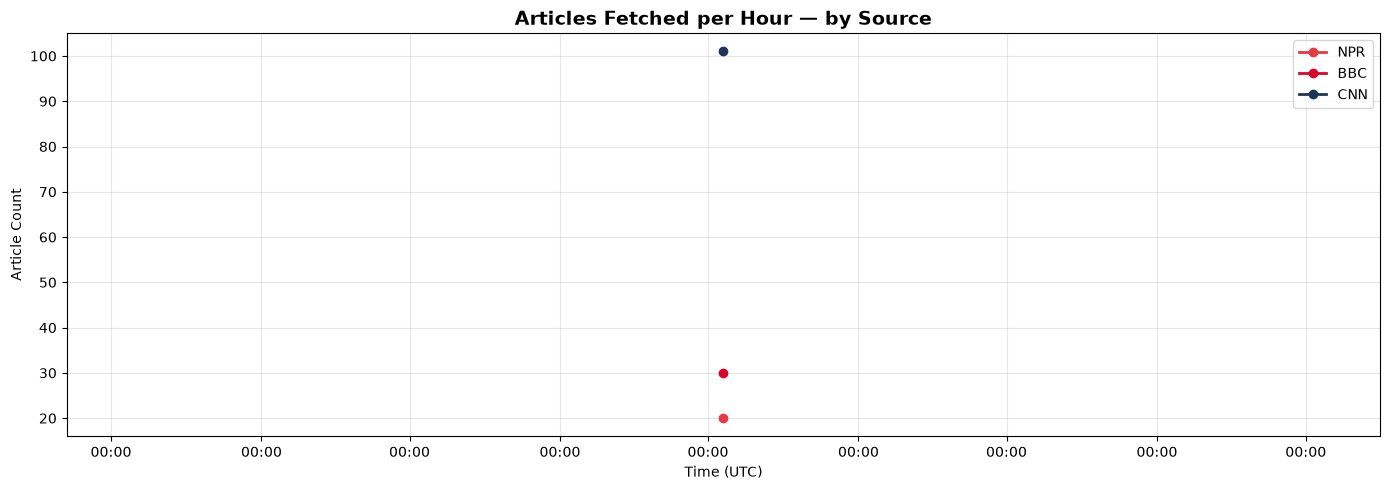

In [ ]:
# Cell 5: Hourly Article Count Trend (using first_seen_at)
df_hourly = pd.read_sql_query("""
    SELECT
        substr(first_seen_at, 1, 10) || ' ' || substr(first_seen_at, 12, 2) || ':00:00' AS hour,
        source,
        COUNT(*) AS count
    FROM articles
    GROUP BY substr(first_seen_at, 1, 13), source
    ORDER BY hour
""", conn)
df_hourly["hour"] = pd.to_datetime(df_hourly["hour"])
pivot = df_hourly.pivot(index="hour", columns="source", values="count").fillna(0)

fig, ax = plt.subplots(figsize=(14, 5))
colors = {"npr": "#e63946", "bbc": "#d90429", "cnn": "#1d3557"}
for src in ["npr", "bbc", "cnn"]:
    if src in pivot.columns:
        ax.plot(pivot.index, pivot[src], marker="o", label=src.upper(), color=colors.get(src), linewidth=2)

ax.set_title("Articles First Seen per Hour — by Source", fontsize=14, fontweight="bold")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Article Count")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 📊 Cell 6: Source Comparison — Bar Chart

A simple horizontal bar chart showing **total article counts per source** (NPR, BBC, CNN). Each bar is colored distinctly and labeled with its exact count above it. This gives you an at-a-glance view of which source has contributed the most articles to the database over time.

CNN typically leads because `lite.cnn.com` lists ~100 headlines compared to NPR's ~20 and BBC's ~30.

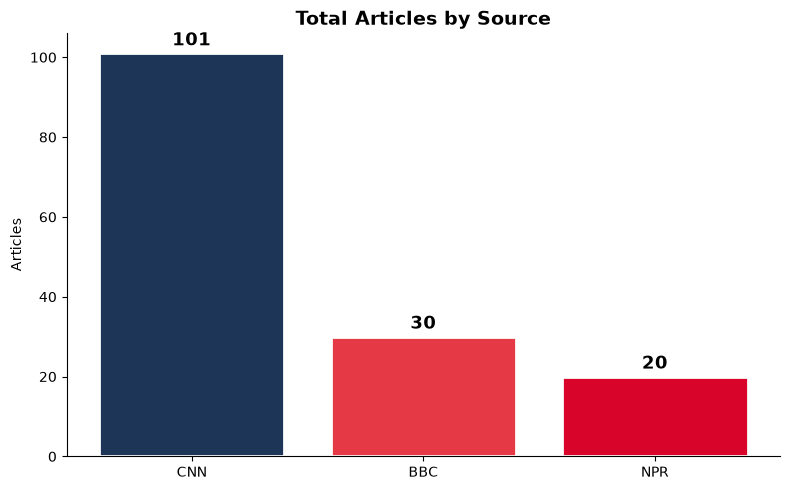

In [11]:
# Cell 6: Source Comparison — Bar Chart
df_counts = pd.read_sql_query(
    "SELECT source, COUNT(*) as cnt FROM articles GROUP BY source ORDER BY cnt DESC",
    conn
)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#1d3557", "#e63946", "#d90429"]
bars = ax.bar(df_counts["source"].str.upper(), df_counts["cnt"], color=colors, edgecolor="white", linewidth=2)
for bar, val in zip(bars, df_counts["cnt"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2, str(val),
            ha="center", fontweight="bold", fontsize=13)
ax.set_title("Total Articles by Source", fontsize=14, fontweight="bold")
ax.set_ylabel("Articles")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

---
## 🔤 Cell 7: Keyword Frequency — What Are the Headlines About?

Extracts all words (4+ letters) from every article title in the database, filters out common English stopwords (the, and, for, from, etc.), and counts frequency. The **top 30 keywords** are plotted as a horizontal bar chart.

This is a lightweight NLP technique for topic detection — no model training needed. Expect to see dominant news themes like *"world", "cup", "iran", "trump", "ukraine"* bubble to the top depending on what's in the news cycle.

The more articles you've collected, the more meaningful this chart becomes.

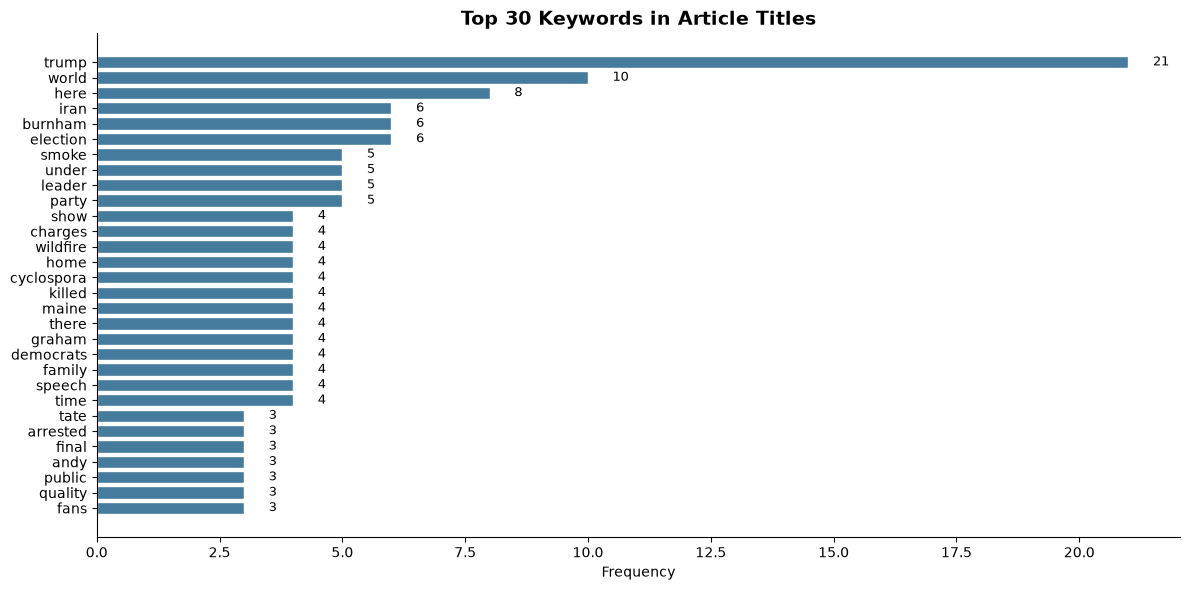

In [12]:
# Cell 7: Word Frequency Analysis — Top Keywords in Titles
STOPWORDS = {"the","a","an","is","in","to","of","and","for","on","at","from","by","with","as","be","it","or","its","after","not","new","over","has","was","are","were","been","will","can","have","had","may","but","that","this","his","her","their","they","you","we","he","she","more","also","says","just","how","what","why","when","who","us","no","out","up","about","into","after","back","first","one","two","three","am"}

all_titles = conn.execute("SELECT title FROM articles").fetchall()
word_counts = Counter()
pattern = re.compile(r"[a-z]{4,}")  # 4+ letter words only

for (title,) in all_titles:
    words = pattern.findall(title.lower())
    for w in words:
        if w not in STOPWORDS:
            word_counts[w] += 1

top_words = word_counts.most_common(30)
words_df = pd.DataFrame(top_words, columns=["word", "count"])

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(words_df["word"], words_df["count"], color="#457b9d", edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("Frequency")
ax.set_title("Top 30 Keywords in Article Titles", fontsize=14, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for i, (word, cnt) in enumerate(top_words):
    ax.text(cnt + 0.5, i, str(cnt), va="center", fontsize=9)
plt.tight_layout()
plt.show()

---
## 💾 Cell 8: Export to CSV & Close

Dumps the **full `articles` table** (all columns: id, source, title, url, published_at, fetched_at, snippet, content) to `news_export.csv` — a flat file you can open in Excel, Google Sheets, or import into another analysis tool. Also **closes the SQLite connection** cleanly, which triggers a WAL checkpoint so any pending data in `news.db-wal` is merged into `news.db`.

In [ ]:
# Cell 8: Export to CSV
df_all = pd.read_sql_query(
    "SELECT * FROM articles ORDER BY fetched_at DESC", conn
)
csv_path = "news_export.csv"
df_all.to_csv(csv_path, index=False)
print(f"✅ Exported {len(df_all):,} articles to {csv_path}")
print(f"   Columns: {', '.join(df_all.columns)}")
print(f"   File size: {Path(csv_path).stat().st_size / 1024:.1f} KB")

conn.close()
print("\n👋 DB connection closed.")

✅ Exported 151 articles to news_export.csv
   Columns: id, source, title, url, published_at, fetched_at, snippet, content
   File size: 109.0 KB

👋 DB connection closed.


: 